In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import sys
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import zscore, variation
from sklearn.preprocessing import normalize, scale, MinMaxScaler
import seaborn as sns

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
def accessData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def accessData2(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes

def accessData3(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes


def accessData4(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def accessData5(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def saveCSV(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=False)

    return print('Files saved')

def saveCSV2(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=True)

    return print('Files saved')


def normalize(dic_data, dic_total, dic_scaling_value):
    """Normalize to desired value (mean, median...)
    1. divide by the total counts in each column
    2. multiply by scaling value"""
    #make a counter for the smaple number to select the scaling_value position
    count = 0
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(dic_total[key], axis='columns')
        #multiply by the scaling value
        data_frame_normal = data_frame_normal_s1.multiply(dic_scaling_value[key])
        count = count + 1
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal

    return dic_normal

def zscores(dic_data):
    """Calculates de z scores for each gene individually"""
    #Create a dictinary to store the dataframes of z scores
    dic_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            #transform the series into list, then to np.array and apply z score funtion from scipy.stats
            #and save it to the Zscore df
            data_gene = np.array(list(dic_data[key].loc[index]))
            df_zscore.loc[index] = zscore(data_gene.astype(float))
        #save the df_zscores to the dictionary
        dic_zscores[key] = df_zscore.astype(float)
    
    return dic_zscores


def scaledZscores(dic_data):
    """Calculates de scaled z scores for each gene individually.
    Normalize the Z score to scaled Z score (-1 to 1)"""
    #Create a dictinary to store the dataframes of z scores
    dic_scaled_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_scaled_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            ## 1.convert the column value of the dataframe to floats
            float_array = dic_data[key].loc[index].values.astype(float)
            # Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
            float_array = float_array.reshape(-1, 1)
            # 2. create a min max processing object
            min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
            scaled_array = min_max_scaler.fit_transform(float_array)
            # 3. convert the scaled array to dataframe. First reshape the array to the original shape
            scaled_array = scaled_array.reshape(len(dic_data[key].columns.values),)
            df_scaled_zscore.loc[index] = scaled_array
        #save the df_zscores to the dictionary 
        #Use astype(float) to ensure the values are numbers for correct plotting
        dic_scaled_zscores[key] = df_scaled_zscore.astype(float)
    
    return dic_scaled_zscores


def meanDataset(dic_data):
    """Sum the different datasets and calculate the mean to create a Mean dataset"""
    #get a list of the keys
    keys = []
    for key in dic_data:
        keys.append(key)
    #create a new dataframe
    mean_dataset = pd.DataFrame(index = dic_data[keys[0]].index.values, columns = dic_data[keys[0]].index.values)
    for element in range(len(keys)):
        #add each dataframe individually
        #first combine the first two dataframes
        if element == 0:
            mean_dataset = dic_data[keys[0]].add(dic_data[keys[1]], axis='index')
        #add the remaining dataframes to the existent sum
        if element > 1:
            mean_dataset = mean_dataset.add(dic_data[keys[element]], axis='index')
    #divide by the number of samples to make the mean
    mean_dataset = mean_dataset.div(len(keys))
    
    #re-normalize z-scores
    #create dic_data 
    dic_data = {'mean': mean_dataset}
    mean_dataset_scaled = scaledZscores(dic_data)
    
    return mean_dataset_scaled


## Anna's formulas for hierarchical clustering
def hierarchicalClustering(df, cth = 100, plot = False, method = 'ward', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

## Anna's formulas for hierarchical clustering
def hierarchicalClustering2(df, cth = 100, plot = False, method = 'average', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

def getClusterByColor(dg, labels):
    """given a dendogram and labels, it groups labels by colors in the dendogram (i.e. clusters)"""
    kk = []
    ii = 0
    cluster = 0
    color = dg['color_list'][0]
    clusters = {cluster: []}
    for i in range(len(dg['icoord'])):
        v = dg['icoord'][i]
        for j in [0,2]:
            vj = int(round((v[j]-5.)/10))
            if (v[j]-5.)/10 == vj and vj not in kk:
                kk.append(vj)
                if dg['color_list'][i] == color:
                    clusters[cluster].append(labels[dg['leaves'][vj]])
                else:
                    color = dg['color_list'][i]
                    cluster += 1
                    clusters[cluster] = [labels[dg['leaves'][vj]]]
    return clusters


def plotHeatmap(dic_data, dg, clusters, figsize, title, type_data, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none')
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].tick_params(top=False, bottom=True, left=False, right=False)
        #add 1 to the count to go to next sample
        count = count + 1
        
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections A-P")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')
    #add the figure title
    fig.suptitle(title, fontsize=13)
    plt.show()
    
    
def ClusterGeneNames(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[1]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterEnsambleID(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[0]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterIndexs(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #create new dictiornary
    idx_cluster={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_idx=[]
        for index in data[start:end]:
            f.write(str(index) + '\n')
            list_idx.append(str(index))
        start = start + len(clusters[key])
        idx_cluster[str(key)]=list_idx
    #close the file when done
    f.close()
    
    return idx_cluster, print(file_name)


def ClusterIndex(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    dic_data={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_index=[]
        for element in data[start:end]:
            f.write(element + '\n')
            list_index.append(element)
        start = start + len(clusters[key])
        dic_data[key]=list_index
    #close the file when done
    f.close()
    
    return print(file_name), dic_data


def plotMeanCluster(dic_data, list_clusters, xlabel = 'Sections A-P', ylabel = 'Scaled z-score'):
    """Plot the specified cluster data"""
    #get cluster data and plot
    for key in dic_data:
        data_frame = dic_data[key]
        #find the column values for the cluster of interest
        for cluster in list_clusters:
            cluster_data = data_frame.loc[str(cluster)]
            #plot the data
            cluster_data.plot(label = cluster+1);
        plt.xlabel(xlabel,fontsize=15);
        plt.ylabel(ylabel,fontsize=15);
        plt.legend(fontsize=15, frameon=False);
        plt.title(key,fontsize=15)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.show();
    
    return plt

In [3]:
path=''

### Merged CpG information

In [4]:
#select only DEG from dataset
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_genes_merged_normalized_DEG.bed']
labels = ['shared_filtered_merged']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData3(file_names, path, labels)
data_normal['shared_filtered_merged']

,M1-10,M1-11,M1-12,M1-13,M1-24,M1-25,M1-27,M1-35,M1-36,M1-38,...,M3-3,M3-4,M3-17,M3-18,M3-19,M3-20,M3-33,M3-34,M3-35,M3-36
ENSMUSG00000042686_Jph1_ProteinCoding,597.132756,250.281771,441.812595,364.878312,200.432652,518.290567,519.055827,530.744293,436.243648,502.655954,...,290.603156,217.506451,302.374370,331.567062,349.940441,370.647328,306.630099,271.751891,333.783107,444.458432
ENSMUSG00000026155_Smap1_ProteinCoding,143.640182,93.855664,214.735731,186.320840,209.584828,243.587676,332.409040,444.967437,226.760312,237.905304,...,400.980616,181.409635,360.293968,375.051267,317.664381,330.359575,378.833517,341.762548,363.870598,368.379962
ENSMUSG00000026154_Sdhaf4_ProteinCoding,2.052003,215.703369,148.093607,147.503999,166.569601,88.011606,269.304650,243.391827,130.657132,98.124367,...,172.464781,195.293026,189.942210,187.525633,160.530930,232.773684,231.613561,215.559127,185.226118,193.199274
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,12.341134,10.674631,10.982611,12.446086,21.331061,4.288843,3.239433,87.015948,...,14.659506,13.883390,4.258794,12.682893,13.589920,18.800951,10.314774,10.133121,28.207023,10.010325
ENSMUSG00000058407_Txndc9_ProteinCoding,137.484174,495.623771,391.213946,346.440312,278.226147,238.253640,731.477647,244.464038,307.746138,278.636173,...,244.899989,208.250857,305.781405,263.622992,280.292101,239.040668,316.944873,308.599605,299.934679,361.372734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,2431.623080,4338.766230,2144.889078,1869.030929,1357.267683,1313.062037,1955.347295,1894.596294,2176.898996,2379.053042,...,438.060544,537.749990,493.168339,537.211114,456.961061,444.955851,417.279492,536.134240,533.112737,440.454302
ENSMUSG00000071708_Sms_ProteinCoding,2191.538776,1811.249660,2620.022735,1571.111669,907.895847,1716.670815,1300.305951,1658.709942,3007.273663,1791.232544,...,169.877809,173.079601,182.276381,178.466424,161.380300,211.286883,155.659316,201.741235,233.178058,183.188949
ENSMUSG00000046873_Mbtps2_ProteinCoding,4711.397968,4771.819558,2436.139839,1790.426824,1325.235067,2643.904197,3107.224611,2131.554857,2877.696341,3211.258757,...,621.735535,831.152309,718.884418,652.263073,680.345372,783.372977,849.562292,553.636904,730.561898,513.529675
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,3365.284263,3298.120971,3470.326863,2518.242606,1431.400307,3866.287610,1825.583338,3017.200889,3435.958634,2118.930900,...,929.585169,578.474602,907.123111,1070.798544,961.486842,991.974009,842.998345,844.733845,959.038786,1051.084131


#### logFC anterior-posterior vs center female sections

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [5]:
data_normal_AP = data_normal['shared_filtered_merged'][[ 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


,M2-36,M2-37,M2-38,M2-39,M1-35,M1-36,M1-38
ENSMUSG00000042686_Jph1_ProteinCoding,306.445253,346.924341,463.393892,287.875486,530.744293,436.243648,502.655954
ENSMUSG00000026155_Smap1_ProteinCoding,408.593671,208.154605,210.349587,186.644546,444.967437,226.760312,237.905304
ENSMUSG00000026154_Sdhaf4_ProteinCoding,315.612419,171.953804,234.300282,122.320719,243.391827,130.657132,98.124367
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,23.128289,22.909361,4.217956,4.288843,3.239433,87.015948
ENSMUSG00000058407_Txndc9_ProteinCoding,307.754848,296.645451,268.664324,355.362780,244.464038,307.746138,278.636173
...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,1936.891153,1011.611268,1021.549231,1880.153816,1894.596294,2176.898996,2379.053042
ENSMUSG00000071708_Sms_ProteinCoding,2058.683497,916.081377,874.721054,1177.864169,1658.709942,3007.273663,1791.232544
ENSMUSG00000046873_Mbtps2_ProteinCoding,3103.740387,1355.518875,1470.364438,2411.616252,2131.554857,2877.696341,3211.258757
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,2408.345389,1502.333234,2131.611902,1840.083236,3017.200889,3435.958634,2118.930900


In [6]:
data_normal_C = data_normal['shared_filtered_merged'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

,M1-10,M1-11,M1-12,M1-13,M2-8,M2-9,M2-10,M2-11,M2-22,M2-23,M2-24,M2-25
ENSMUSG00000042686_Jph1_ProteinCoding,597.132756,250.281771,441.812595,364.878312,465.475679,340.161984,434.365826,280.697562,422.796091,486.028553,406.810911,507.495622
ENSMUSG00000026155_Smap1_ProteinCoding,143.640182,93.855664,214.735731,186.320840,177.687437,227.752133,169.081999,163.740244,283.863096,332.750087,207.859590,257.018961
ENSMUSG00000026154_Sdhaf4_ProteinCoding,2.052003,215.703369,148.093607,147.503999,238.733428,124.139575,220.583988,67.835244,142.931066,200.814192,184.104208,179.445966
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,12.341134,10.674631,4.360428,19.549539,27.208598,4.678293,10.994697,20.372454,1.979615,71.965309
ENSMUSG00000058407_Txndc9_ProteinCoding,137.484174,495.623771,391.213946,346.440312,162.425939,135.869298,275.972918,207.014452,279.865025,332.750087,388.994375,338.330415
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,2431.623080,4338.766230,2144.889078,1869.030929,1313.578905,1057.630078,1190.376145,1873.656226,1484.284148,1698.674642,2077.606089,1163.594935
ENSMUSG00000071708_Sms_ProteinCoding,2191.538776,1811.249660,2620.022735,1571.111669,928.771143,884.616655,1660.696189,2879.489157,958.537709,1162.200012,1850.940156,671.053143
ENSMUSG00000046873_Mbtps2_ProteinCoding,4711.397968,4771.819558,2436.139839,1790.426824,2596.634816,1982.323288,2236.935417,2673.644278,1945.061921,2030.454612,2660.602748,1373.883176
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,3365.284263,3298.120971,3470.326863,2518.242606,2035.229723,1642.161304,2229.161532,2652.591961,2231.923571,2629.986839,2417.110086,1933.717205


In [7]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered_merged'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

,A-P,C
ENSMUSG00000042686_Jph1_ProteinCoding,410.611838,416.494805
ENSMUSG00000026155_Smap1_ProteinCoding,274.767923,204.858830
ENSMUSG00000026154_Sdhaf4_ProteinCoding,188.051507,155.995054
ENSMUSG00000061518_Cox5b_ProteinCoding,20.685690,15.343725
ENSMUSG00000058407_Txndc9_ProteinCoding,294.181965,290.998726
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,1757.250543,1886.975874
ENSMUSG00000071708_Sms_ProteinCoding,1640.652321,1599.185584
ENSMUSG00000046873_Mbtps2_ProteinCoding,2365.964273,2600.777037
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,2350.637741,2535.321410


In [8]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


ENSMUSG00000042686_Jph1_ProteinCoding      -0.020523
ENSMUSG00000026155_Smap1_ProteinCoding      0.423584
ENSMUSG00000026154_Sdhaf4_ProteinCoding     0.269628
ENSMUSG00000061518_Cox5b_ProteinCoding      0.430984
ENSMUSG00000058407_Txndc9_ProteinCoding     0.015696
                                              ...   
ENSMUSG00000041115_Iqsec2_ProteinCoding    -0.102756
ENSMUSG00000071708_Sms_ProteinCoding        0.036932
ENSMUSG00000046873_Mbtps2_ProteinCoding    -0.136514
ENSMUSG00000040990_Sh3kbp1_ProteinCoding   -0.109116
ENSMUSG00000049775_Tmsb4x_ProteinCoding     0.564959
Length: 682, dtype: float64

In [9]:
list_idx=[index.split('_')[1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

,Gene,log2FC A-P vs C
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.020523
ENSMUSG00000026155_Smap1_ProteinCoding,Smap1,0.423584
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Sdhaf4,0.269628
ENSMUSG00000061518_Cox5b_ProteinCoding,Cox5b,0.430984
ENSMUSG00000058407_Txndc9_ProteinCoding,Txndc9,0.015696
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Iqsec2,-0.102756
ENSMUSG00000071708_Sms_ProteinCoding,Sms,0.036932
ENSMUSG00000046873_Mbtps2_ProteinCoding,Mbtps2,-0.136514
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Sh3kbp1,-0.109116


In [10]:
df = pd.read_excel("DEG.xlsx", header=0, index_col=0)
list1=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] >= 0.4)].index
list2=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] <= -0.4)].index
df_sig=df.loc[df_FC.index]
# Create a new column based on index membership
df_sig['Annotation'] = np.where(df_sig.index.isin(list1), 'Central', 
                    np.where(df_sig.index.isin(list2), 'Proximal-distal', np.nan))
# Check the result
list_ann=df_sig.drop(['Mean z-score difference', 'Proximal-distal_s', 'Central_s', 'p_value', 'adj_p_value'], axis=1)
list_ann

,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Proximal-distal
ENSMUSG00000026155_Smap1_ProteinCoding,Proximal-distal
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Central
ENSMUSG00000061518_Cox5b_ProteinCoding,Central
ENSMUSG00000058407_Txndc9_ProteinCoding,Proximal-distal
...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Central
ENSMUSG00000071708_Sms_ProteinCoding,Proximal-distal
ENSMUSG00000046873_Mbtps2_ProteinCoding,Proximal-distal
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Central


In [11]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.020523,Proximal-distal
ENSMUSG00000021215_Net1_ProteinCoding,Net1,-0.159890,Proximal-distal
ENSMUSG00000030591_Psmd8_ProteinCoding,Psmd8,-0.233011,Proximal-distal
ENSMUSG00000038132_Rbm24_ProteinCoding,Rbm24,-0.661661,Proximal-distal
ENSMUSG00000001794_Capns1_ProteinCoding,Capns1,0.416460,Proximal-distal
...,...,...,...
ENSMUSG00000022108_Itm2b_ProteinCoding,Itm2b,0.195791,Central
ENSMUSG00000022043_Trim35_ProteinCoding,Trim35,-0.523096,Central
ENSMUSG00000022040_Ephx2_ProteinCoding,Ephx2,0.009020,Central
ENSMUSG00000021273_Fdft1_ProteinCoding,Fdft1,-0.089458,Central


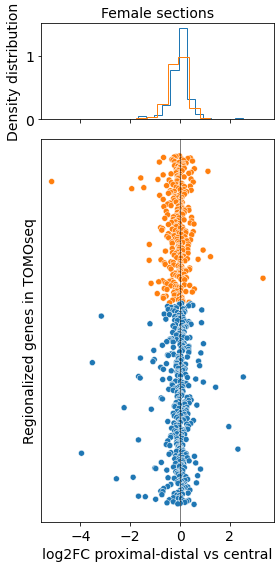

In [12]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Female sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False  # disables legend
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD all genes female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

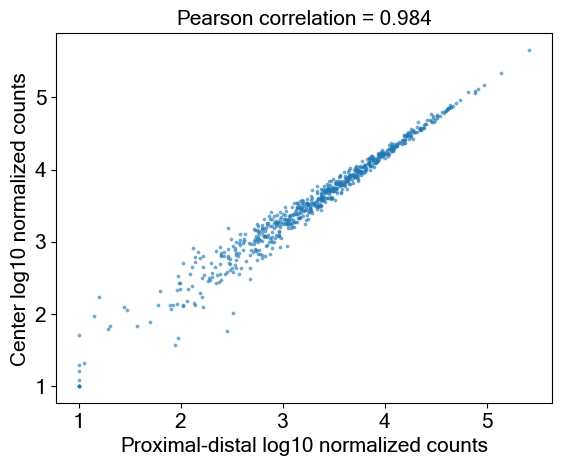

In [59]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

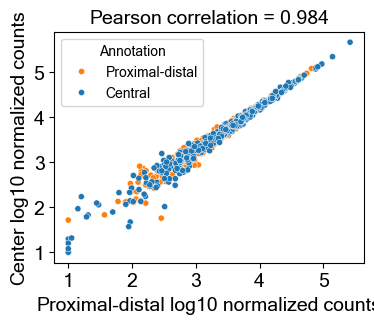

In [60]:
data_frame_ann=pd.concat([data_frame, list_ann], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=20)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD all genes female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


#### logFC anterior-posterior vs center male sections

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [13]:
data_normal_AP = data_normal['shared_filtered_merged'][['M3-1', 'M3-2', 'M3-3', 'M3-4','M3-33', 'M3-34', 'M3-35', 'M3-36']]
data_normal_AP


,M3-1,M3-2,M3-3,M3-4,M3-33,M3-34,M3-35,M3-36
ENSMUSG00000042686_Jph1_ProteinCoding,339.674203,231.225212,290.603156,217.506451,306.630099,271.751891,333.783107,444.458432
ENSMUSG00000026155_Smap1_ProteinCoding,367.738453,250.865964,400.980616,181.409635,378.833517,341.762548,363.870598,368.379962
ENSMUSG00000026154_Sdhaf4_ProteinCoding,222.578537,177.659526,172.464781,195.293026,231.613561,215.559127,185.226118,193.199274
ENSMUSG00000061518_Cox5b_ProteinCoding,9.677328,28.568366,14.659506,13.883390,10.314774,10.133121,28.207023,10.010325
ENSMUSG00000058407_Txndc9_ProteinCoding,313.545418,191.050948,244.899989,208.250857,316.944873,308.599605,299.934679,361.372734
...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,583.542861,593.686356,438.060544,537.749990,417.279492,536.134240,533.112737,440.454302
ENSMUSG00000071708_Sms_ProteinCoding,142.256717,117.844510,169.877809,173.079601,155.659316,201.741235,233.178058,183.188949
ENSMUSG00000046873_Mbtps2_ProteinCoding,788.702209,1078.455817,621.735535,831.152309,849.562292,553.636904,730.561898,513.529675
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,913.539736,383.887418,929.585169,578.474602,842.998345,844.733845,959.038786,1051.084131


In [14]:
data_normal_C = data_normal['shared_filtered_merged'][['M3-17', 'M3-18','M3-19', 'M3-20']]
data_normal_C

,M3-17,M3-18,M3-19,M3-20
ENSMUSG00000042686_Jph1_ProteinCoding,302.374370,331.567062,349.940441,370.647328
ENSMUSG00000026155_Smap1_ProteinCoding,360.293968,375.051267,317.664381,330.359575
ENSMUSG00000026154_Sdhaf4_ProteinCoding,189.942210,187.525633,160.530930,232.773684
ENSMUSG00000061518_Cox5b_ProteinCoding,4.258794,12.682893,13.589920,18.800951
ENSMUSG00000058407_Txndc9_ProteinCoding,305.781405,263.622992,280.292101,239.040668
...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,493.168339,537.211114,456.961061,444.955851
ENSMUSG00000071708_Sms_ProteinCoding,182.276381,178.466424,161.380300,211.286883
ENSMUSG00000046873_Mbtps2_ProteinCoding,718.884418,652.263073,680.345372,783.372977
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,907.123111,1070.798544,961.486842,991.974009


In [15]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered_merged'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

,A-P,C
ENSMUSG00000042686_Jph1_ProteinCoding,304.454069,338.632300
ENSMUSG00000026155_Smap1_ProteinCoding,331.730162,345.842298
ENSMUSG00000026154_Sdhaf4_ProteinCoding,199.199244,192.693115
ENSMUSG00000061518_Cox5b_ProteinCoding,15.681729,12.333140
ENSMUSG00000058407_Txndc9_ProteinCoding,280.574888,272.184292
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,510.002565,483.074091
ENSMUSG00000071708_Sms_ProteinCoding,172.103274,183.352497
ENSMUSG00000046873_Mbtps2_ProteinCoding,745.917080,708.716460
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,812.917754,982.845627


In [16]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


ENSMUSG00000042686_Jph1_ProteinCoding      -0.153495
ENSMUSG00000026155_Smap1_ProteinCoding     -0.060104
ENSMUSG00000026154_Sdhaf4_ProteinCoding     0.047907
ENSMUSG00000061518_Cox5b_ProteinCoding      0.346545
ENSMUSG00000058407_Txndc9_ProteinCoding     0.043802
                                              ...   
ENSMUSG00000041115_Iqsec2_ProteinCoding     0.078260
ENSMUSG00000071708_Sms_ProteinCoding       -0.091345
ENSMUSG00000046873_Mbtps2_ProteinCoding     0.073807
ENSMUSG00000040990_Sh3kbp1_ProteinCoding   -0.273855
ENSMUSG00000049775_Tmsb4x_ProteinCoding    -0.039670
Length: 682, dtype: float64

In [17]:
list_idx=[index.split('_')[1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

,Gene,log2FC A-P vs C
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.153495
ENSMUSG00000026155_Smap1_ProteinCoding,Smap1,-0.060104
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Sdhaf4,0.047907
ENSMUSG00000061518_Cox5b_ProteinCoding,Cox5b,0.346545
ENSMUSG00000058407_Txndc9_ProteinCoding,Txndc9,0.043802
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Iqsec2,0.078260
ENSMUSG00000071708_Sms_ProteinCoding,Sms,-0.091345
ENSMUSG00000046873_Mbtps2_ProteinCoding,Mbtps2,0.073807
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Sh3kbp1,-0.273855


In [18]:
df = pd.read_excel("DEG.xlsx", header=0, index_col=0)
list1=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] >= 0.4)].index
list2=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] <= -0.4)].index
df_sig=df.loc[df_FC.index]
# Create a new column based on index membership
df_sig['Annotation'] = np.where(df_sig.index.isin(list1), 'Central', 
                    np.where(df_sig.index.isin(list2), 'Proximal-distal', np.nan))
# Check the result
list_ann=df_sig.drop(['Mean z-score difference', 'Proximal-distal_s', 'Central_s', 'p_value', 'adj_p_value'], axis=1)
list_ann

,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Proximal-distal
ENSMUSG00000026155_Smap1_ProteinCoding,Proximal-distal
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Central
ENSMUSG00000061518_Cox5b_ProteinCoding,Central
ENSMUSG00000058407_Txndc9_ProteinCoding,Proximal-distal
...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Central
ENSMUSG00000071708_Sms_ProteinCoding,Proximal-distal
ENSMUSG00000046873_Mbtps2_ProteinCoding,Proximal-distal
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Central


In [19]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.153495,Proximal-distal
ENSMUSG00000021215_Net1_ProteinCoding,Net1,-0.059267,Proximal-distal
ENSMUSG00000030591_Psmd8_ProteinCoding,Psmd8,0.201187,Proximal-distal
ENSMUSG00000038132_Rbm24_ProteinCoding,Rbm24,0.082776,Proximal-distal
ENSMUSG00000001794_Capns1_ProteinCoding,Capns1,0.034271,Proximal-distal
...,...,...,...
ENSMUSG00000022108_Itm2b_ProteinCoding,Itm2b,-0.066672,Central
ENSMUSG00000022043_Trim35_ProteinCoding,Trim35,-0.073253,Central
ENSMUSG00000022040_Ephx2_ProteinCoding,Ephx2,-0.145513,Central
ENSMUSG00000021273_Fdft1_ProteinCoding,Fdft1,-0.068907,Central


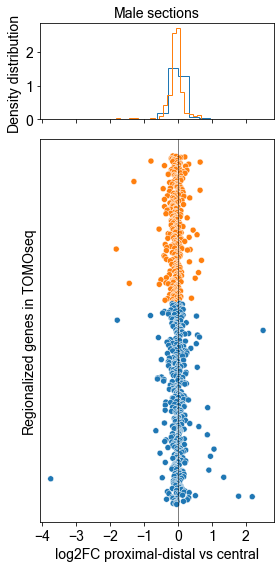

In [20]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Male sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False  # disables legend
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD all genes male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

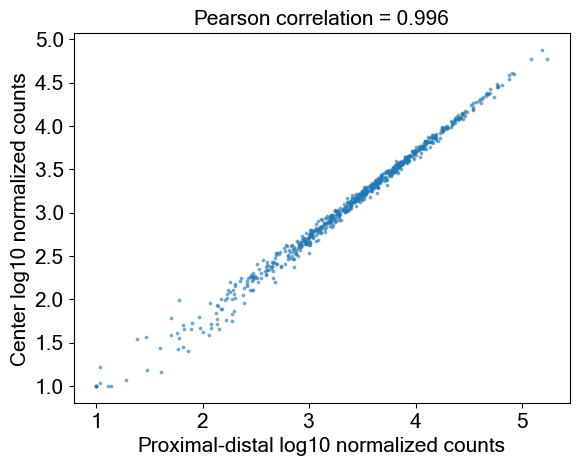

In [23]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

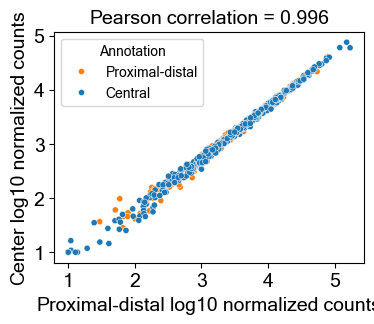

In [24]:
data_frame_ann=pd.concat([data_frame, list_ann], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=20)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD all genes male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### Unmerged CpG information

In [21]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_genes_normalized_DEG.bed']
labels = ['shared_filtered']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData4(file_names, path, labels)
data_normal['shared_filtered']

/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_90938/1401350171.py:59: DtypeWarning: Columns (0,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)


M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  18.468023   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    14.819315   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   4.939772   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG0000

#### Reproducibility 

In [22]:
data_total_norm={}
data_total_norm['Muscle_1']= data_normal['shared_filtered'].iloc[:,:10].sum(axis=1)
data_total_norm['Muscle_2']= data_normal['shared_filtered'].iloc[:,10:22].sum(axis=1)
data_total_norm['Muscle_3']= data_normal['shared_filtered'].iloc[:,22:].sum(axis=1)
data_total_norm

{'Muscle_1': chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
 1    16964654   16964655   CGG    44281     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding        0.000000
      16965302   16965303   CGG    44282     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding        0.000000
      16965419   16965420   CGG    44283     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding       14.819315
      16966970   16966971   CGG    44284     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding        0.000000
      16967673   16967674   CCGG   44285     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding        0.000000
                                                                                                                                ...    
 X    167209231  167209232  CCGG   10922866  X    

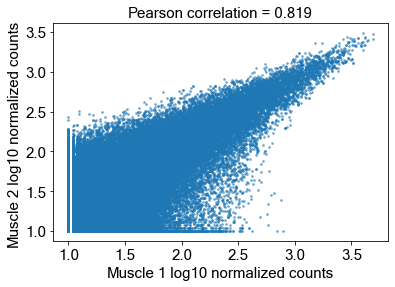

In [23]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_2'])

data_frame.plot(x='Muscle_1', y='Muscle_2', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.show()

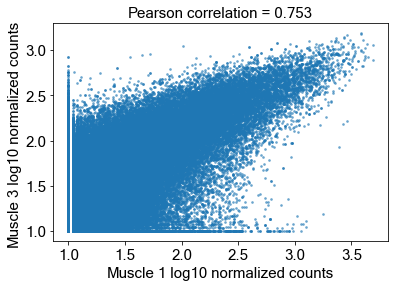

In [24]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_1', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

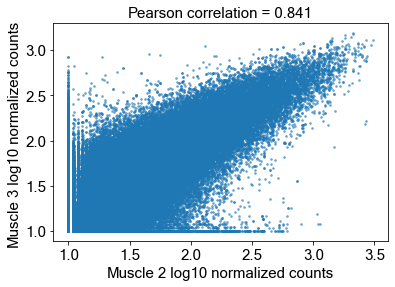

In [25]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_2'].index)
my_list1=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_2'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_2', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

#### logFC anterior-posterior vs center female

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [26]:
data_normal_AP = data_normal['shared_filtered'][[ 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


M2-36  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  18.334331   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M2-37  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   8.044622   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  14.078089   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  14.078089   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  27.150601   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  26.145023   

                                                                                                                     M2-38  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG0000

In [27]:
data_normal_C = data_normal['shared_filtered'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  18.468023   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    14.819315   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   4.939772   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG0000

In [28]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

A-P  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  51.515169   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  29.146794   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  12.502439   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  14.520582   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   6.963151   

                                                                                                                         C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     1.234943  
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.647554  
...                                                                                                                    ...  
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  26.736666  
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  11.524504  
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   7.267769  
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   7.401105  
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   2.741267  

[220502 rows x 2 columns]

In [29]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
1    16964654   16964655   CGG    44281     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16965302   16965303   CGG    44282     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16965419   16965420   CGG    44283     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -3.738706
     16966970   16966971   CGG    44284     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16967673   16967674   CCGG   44285     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -2.902178
                                                                                                                              ...   
X    167209231  167209232  CCGG   10922866  X      167207093  167209315  -       

In [30]:
list_idx=[index[-1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
...                                                                                                                                                  ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -3.738706  
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -2.902178  
...                                                                                                                          ...  
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.946178  
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.338633  
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.782625  
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.972287  
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.344897  

[220502 rows x 2 columns]

In [31]:
list_ann2=pd.DataFrame(index=df_FC.index, columns=['Annotation'])
for index in df_FC.index:
    list_ann2.loc[index]['Annotation']=list_ann['Annotation'].loc[df_FC.loc[index]['Gene']]
#list_ann2["Annotation"] = list_ann2["Annotation"].str.replace("A-P", "PD", regex=False)
list_ann2

Annotation
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                    
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
...                                                                                                                          ...
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central

[220502 rows x 1 columns]

In [32]:
df_FC_ann=pd.concat([df_FC, list_ann2], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
11  95713166  95713167  CCG   6890677  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713274  95713275  GCGC  6890697  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713271  95713272  CGG   6890696  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713268  95713269  CGG   6890695  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
...                                                                                                                                                  ...   
15  76306289  76306290  CCG   8790641  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306314  76306315  CGG   8790642  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306328  76306329  CGG   8790643  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306357  76306358  CGG   8790644  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
X   167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                       
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000   
11  95713166  95713167  CCG   6890677  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713274  95713275  GCGC  6890697  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713271  95713272  CGG   6890696  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713268  95713269  CGG   6890695  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
...                                                                                                                          ...   
15  76306289  76306290  CCG   8790641  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding          1.024904   
    76306314  76306315  CGG   8790642  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -0.275482   
    76306328  76306329  CGG   8790643  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -0.418439   
    76306357  76306358  CGG   8790644  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -1.087510   
X   167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.344897   

                                                                                                                      Annotation  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal  
11  95713

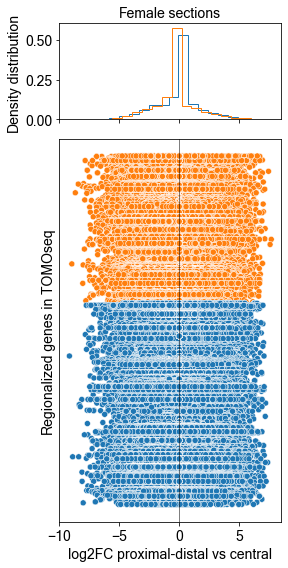

In [33]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Female sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False,  # disables legend
    rasterized=True
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD individual genes female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

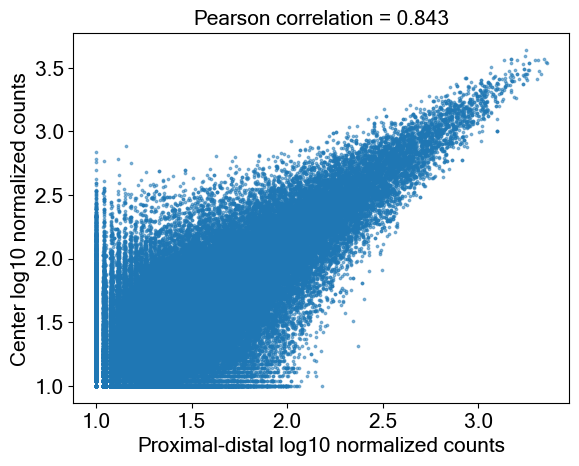

In [38]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

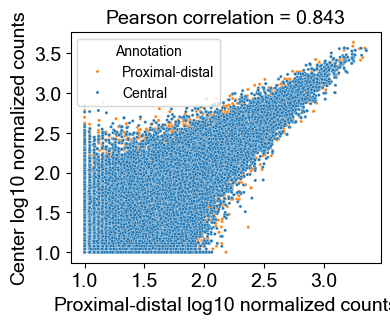

In [39]:
data_frame_ann=pd.concat([data_frame, list_ann2], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=5, rasterized=True)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD indivual genes female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


#### logFC anterior-posterior vs center male

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [34]:
data_normal_AP = data_normal['shared_filtered'][['M3-1', 'M3-2', 'M3-3', 'M3-4','M3-33', 'M3-34', 'M3-35', 'M3-36']]
data_normal_AP


M3-1  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                            
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
...                                                                                                               ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   

                                                                                                                 M3-2  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                            
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.0   
...                                                                                                               ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.0   

                                                                                                                     M3-3  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    3.449296   
...                                                                                       

In [35]:
data_normal_C = data_normal['shared_filtered'][['M3-17', 'M3-18','M3-19', 'M3-20']]
data_normal_C

M3-17  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                                                                                                ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   

                                                                                                                    M3-18  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.905921   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.905921   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.905921   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   

                                                                                                                 M3-19  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                           

In [36]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

A-P  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.117213   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    1.363111   
...                                                                                                                   ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.693624   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.693624   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.693624   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.115149   

                                                                                                                       C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                              
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.00000  
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.00000  
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.00000  
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.00000  
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.00000  
...                                                                                                                  ...  
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.00000  
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.22648  
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.22648  
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.22648  
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.00000  

[220502 rows x 2 columns]

In [37]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
1    16964654   16964655   CGG    44281     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16965302   16965303   CGG    44282     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16965419   16965420   CGG    44283     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      1.119113
     16966970   16966971   CGG    44284     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     16967673   16967674   CCGG   44285     1      16964560   17097889   -       ENSMUSG00000042686_Jph1_ProteinCoding      3.870967
                                                                                                                              ...   
X    167209231  167209232  CCGG   10922866  X      167207093  167209315  -       

In [38]:
list_idx=[index[-1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
...                                                                                                                                                  ...   
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           1.119113  
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           3.870967  
...                                                                                                                          ...  
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.000000  
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.614768  
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.614768  
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.614768  
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.105337  

[220502 rows x 2 columns]

In [39]:
list_ann2=pd.DataFrame(index=df_FC.index, columns=['Annotation'])
for index in df_FC.index:
    list_ann2.loc[index]['Annotation']=list_ann['Annotation'].loc[df_FC.loc[index]['Gene']]
#list_ann2["Annotation"] = list_ann2["Annotation"].str.replace("A-P", "PD", regex=False)
list_ann2

Annotation
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                    
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16965302  16965303  CGG   44282    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16965419  16965420  CGG   44283    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16966970  16966971  CGG   44284    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    16967673  16967674  CCGG  44285    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
...                                                                                                                          ...
X   167209231 167209232 CCGG  10922866 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209247 167209248 GCGC  10922867 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209250 167209251 CCG   10922868 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209258 167209259 CCGG  10922869 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central

[220502 rows x 1 columns]

In [40]:
df_FC_ann=pd.concat([df_FC, list_ann2], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
11  95713166  95713167  CCG   6890677  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713274  95713275  GCGC  6890697  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713271  95713272  CGG   6890696  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
    95713268  95713269  CGG   6890695  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding  ENSMUSG00000075595_Zfp652_ProteinCoding   
...                                                                                                                                                  ...   
15  76306289  76306290  CCG   8790641  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306314  76306315  CGG   8790642  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306328  76306329  CGG   8790643  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
    76306357  76306358  CGG   8790644  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding    ENSMUSG00000022562_Oplah_ProteinCoding   
X   167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                       
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000   
11  95713166  95713167  CCG   6890677  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713274  95713275  GCGC  6890697  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713271  95713272  CGG   6890696  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
    95713268  95713269  CGG   6890695  11    95712673  95835115  +      ENSMUSG00000075595_Zfp652_ProteinCoding         0.000000   
...                                                                                                                          ...   
15  76306289  76306290  CCG   8790641  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -0.179440   
    76306314  76306315  CGG   8790642  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -0.189086   
    76306328  76306329  CGG   8790643  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding         -0.416033   
    76306357  76306358  CGG   8790644  15    76296601  76328015  -      ENSMUSG00000022562_Oplah_ProteinCoding          0.086223   
X   167209270 167209271 CGG   10922870 X     167207093 167209315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.105337   

                                                                                                                      Annotation  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   16964654  16964655  CGG   44281    1     16964560  17097889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal  
11  95713

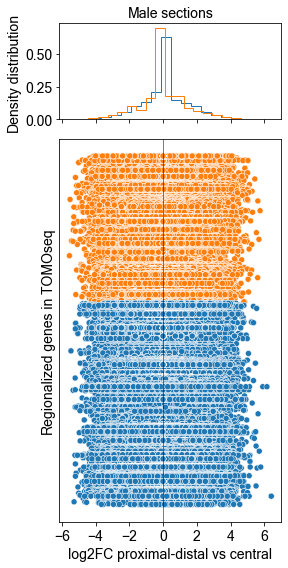

In [43]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Male sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False,  # disables legend
    rasterized=True
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD individual genes male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

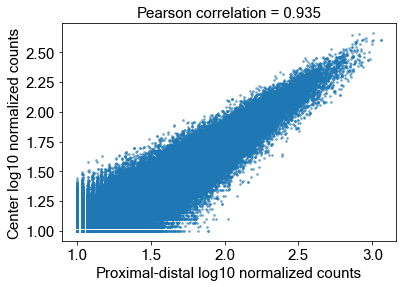

In [42]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

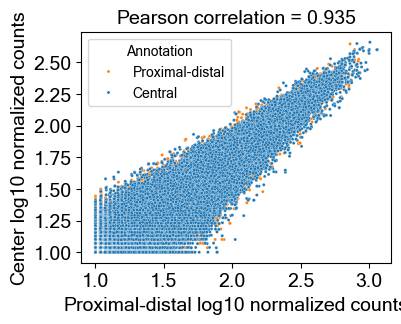

In [49]:
data_frame_ann=pd.concat([data_frame, list_ann2], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=5, rasterized=True)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD indivual genes male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
